In [17]:
from sklearn.cluster import DBSCAN
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Feature definitions
behavioral_features = [
    'income', 'frq', 'per_net_purchase', 'spent_online'
]

preference_features = [
    'clothes', 'kitchen', 'small_appliances',
    'toys', 'house_keeping'
]

metric_features = behavioral_features + preference_features


In [3]:
df = pd.read_csv("df_preprocessed.csv")
df.head()

,Unnamed: 0,YoB,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,...,oh_description_Kind of OK,oh_description_Meh...,oh_description_OK nice!,oh_description_Take my money!!,oh_has_dependents_1.0,oh_marital_status_Married,oh_marital_status_Single,oh_marital_status_Together,oh_marital_status_Whatever,oh_marital_status_Widow
0,0,1946,0.756488,1.206285,0.050607,1402,-0.574129,-0.259907,1.229637,0.373941,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1936,1.564682,1.114566,-0.809510,1537,0.194413,-0.769611,0.752907,-0.383254,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1990,-1.512384,-0.811540,0.093613,44,-0.787614,1.524054,-0.359464,-0.761851,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,3,1955,0.857835,0.564250,-0.752169,888,0.407897,0.377222,-0.756739,-0.130856,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,4,1955,0.795370,1.022847,-0.522805,1138,0.365201,-0.259907,-0.041644,-0.383254,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8998 entries, 0 to 8997
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      8998 non-null   int64  
 1   YoB                             8998 non-null   int64  
 2   income                          8998 non-null   float64
 3   frq                             8998 non-null   float64
 4   rcn                             8998 non-null   float64
 5   mnt                             8998 non-null   int64  
 6   clothes                         8998 non-null   float64
 7   kitchen                         8998 non-null   float64
 8   small_appliances                8998 non-null   float64
 9   toys                            8998 non-null   float64
 10  house_keeping                   8998 non-null   float64
 11  has_dependents                  8998 non-null   bool   
 12  per_net_purchase                89

In [5]:
df.describe()

,Unnamed: 0,YoB,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,...,oh_description_Kind of OK,oh_description_Meh...,oh_description_OK nice!,oh_description_Take my money!!,oh_has_dependents_1.0,oh_marital_status_Married,oh_marital_status_Single,oh_marital_status_Together,oh_marital_status_Whatever,oh_marital_status_Widow
count,8998.000000,8998.000000,8.998000e+03,8.998000e+03,8.998000e+03,8998.000000,8.998000e+03,8.998000e+03,8.998000e+03,8.998000e+03,...,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000,8998.000000
mean,4498.500000,1966.059680,9.416784e-17,-2.171585e-17,5.922506e-18,622.162814,4.708392e-17,1.085793e-18,4.540588e-17,1.697785e-17,...,0.232274,0.234163,0.381640,0.147366,0.716381,0.383419,0.254834,0.235386,0.001667,0.049455
std,2597.643195,17.296552,1.000056e+00,1.000056e+00,1.000056e+00,646.768205,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,...,0.422306,0.423498,0.485816,0.354490,0.450779,0.486246,0.435792,0.424263,0.040798,0.216829
min,0.000000,1936.000000,-2.178968e+00,-1.545294e+00,-8.955222e-01,6.000000,-2.111215e+00,-8.970364e-01,-2.186929e+00,-8.880507e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2249.250000,1951.000000,-8.020212e-01,-9.032589e-01,-5.228047e-01,63.000000,-7.449167e-01,-6.421848e-01,-7.567389e-01,-6.356523e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4498.500000,1966.000000,2.420362e-03,-2.612237e-01,-1.357519e-01,383.000000,2.362608e-02,-3.873331e-01,-4.164368e-02,-3.832539e-01,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6747.750000,1981.000000,8.054538e-01,7.476888e-01,2.369656e-01,1076.000000,7.921689e-01,3.772218e-01,6.734515e-01,3.739412e-01,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,8997.000000,1996.000000,2.567792e+00,3.590988e+00,6.974551e+00,3052.000000,2.073073e+00,8.659900e+00,3.613287e+00,6.936299e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


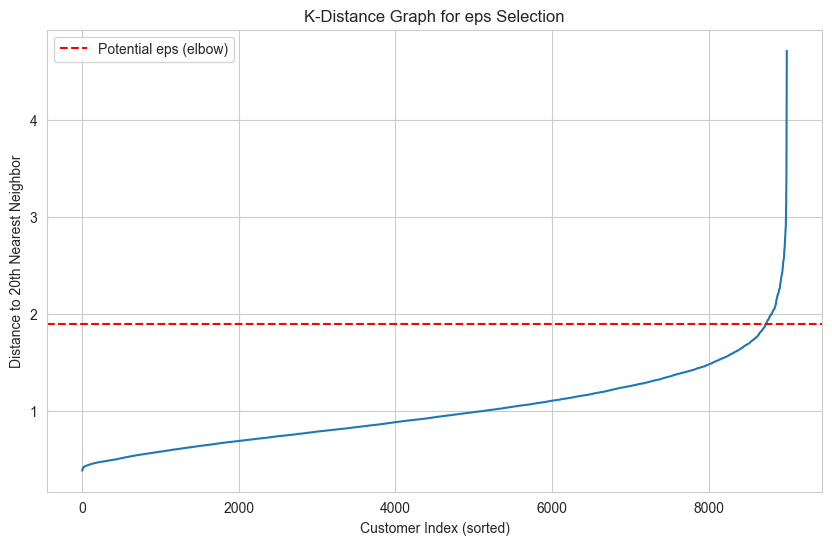

In [6]:

neigh = NearestNeighbors(n_neighbors=20) # n_features * 2 as a rule of thumb
neigh.fit(df[metric_features])
distances, _ = neigh.kneighbors(df[metric_features])
# matrix of n_samples x n_neighbors nearest neighbors distances
distances = np.sort(distances[:, -1])
# distances for every sample to the 20th nearest neighbor, sorted


plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer Index (sorted)")
plt.ylabel("Distance to 20th Nearest Neighbor")
plt.grid(True)

plt.axhline(y=1.9, color='r', linestyle='--', label='Potential eps (elbow)')

plt.legend()
plt.show()

In [7]:
dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=-1)
labels = dbscan.fit_predict(df[metric_features])

print("Outliers detected:", Counter(labels)[-1])

df = df[labels != -1].copy()
df.shape

Outliers detected: 50


(8948, 35)

In [21]:
df.to_csv("df_cleaned.csv", index=False)

# Behavioral features


### Using KMeans

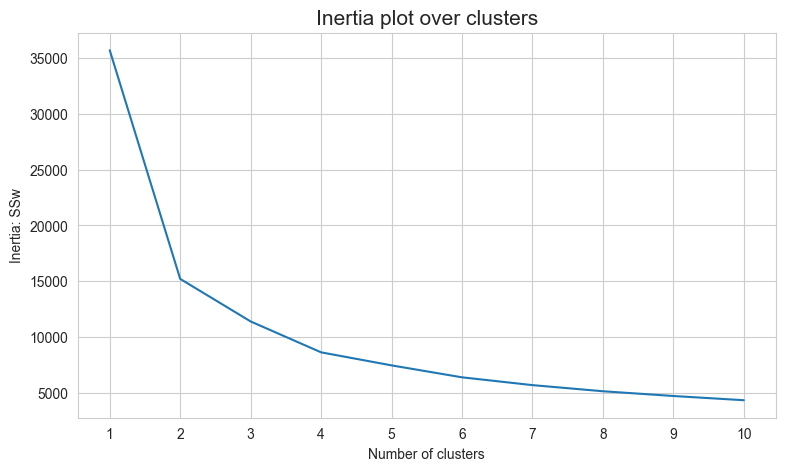

In [8]:
range_clusters = range(1, 11)
inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df[behavioral_features])
    inertia.append(kmclust.inertia_)  # save the inertia of the given cluster solution

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [9]:
kmeans_behav = KMeans(n_clusters=4, n_init=20, random_state=42)
df['behavior_labels'] = kmeans_behav.fit_predict(df[behavioral_features])

In [11]:
df['behavior_labels'].value_counts()

behavior_labels
1    3737
0    2234
3    1962
2    1015
Name: count, dtype: int64

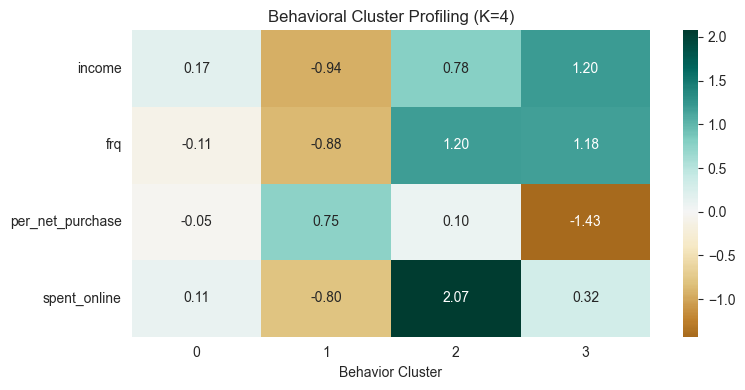

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

km_profile = df.groupby('behavior_labels')[behavioral_features].mean().T

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Behavior Cluster")
ax.set_title("Behavioral Cluster Profiling (K=4)")
plt.tight_layout()
plt.show()

# Product Clustering

### Using KMeans for Clustering

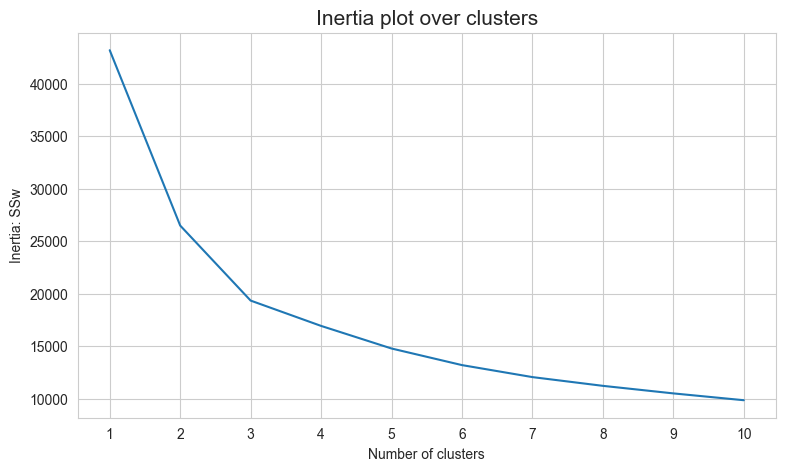

In [12]:
range_clusters = range(1, 11)
inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df[preference_features])
    inertia.append(kmclust.inertia_)  # save the inertia of the given cluster solution

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [13]:
kmeans_pref = KMeans(n_clusters=3, n_init=20, random_state=42)
df['product_labels'] = kmeans_pref.fit_predict(df[preference_features])

In [14]:
df['product_labels'].value_counts()

product_labels
1    3705
0    3677
2    1566
Name: count, dtype: int64

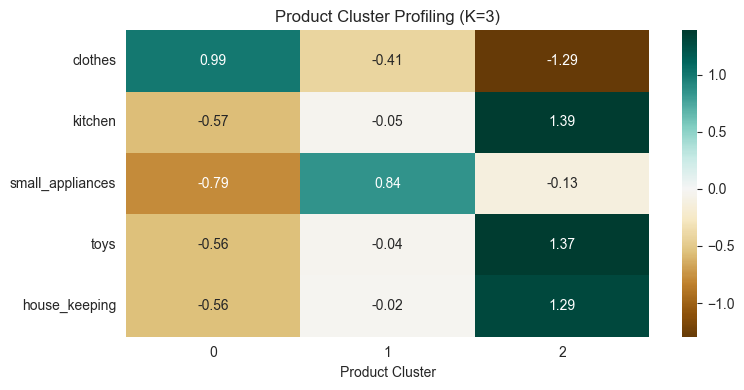

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

km_profile_2 = df.groupby('product_labels')[preference_features].mean().T

sns.heatmap(
    km_profile_2,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Product Cluster")
ax.set_title("Product Cluster Profiling (K=3)")
plt.tight_layout()
plt.show()

# Merge the Prespectives

In [18]:
df_centroids = df.groupby(
    ['behavior_labels', 'product_labels']
)[metric_features].mean()

hclust = AgglomerativeClustering(n_clusters=7, linkage='ward')
merged_labels = hclust.fit_predict(df_centroids)

df_centroids['merged_labels'] = merged_labels
mapper = df_centroids['merged_labels'].to_dict()

df['labels'] = df.apply(
    lambda row: mapper[(row['behavior_labels'], row['product_labels'])],
    axis=1
)

df['labels'].value_counts().sort_index()

labels
0     293
1    1713
2    2153
3    1076
4     449
5    2542
6     722
Name: count, dtype: int64

In [22]:
df.to_csv("final_clustered_data.csv", index=False)

## Evalaute the R2

In [20]:
def get_ss(df, features):
    return np.sum(df[features].var() * (df[features].count() - 1))

def get_ssw(df, features, label_col):
    return df.groupby(label_col)[features].apply(
        lambda x: get_ss(x, features)
    ).sum()

def get_rsq(df, features, label_col):
    sst = get_ss(df, features)
    ssw = get_ssw(df, features, label_col)
    return 1 - (ssw / sst)

r2 = get_rsq(df, metric_features, 'labels')
print("Final R²:", round(r2,4))

Final R²: 0.5938
